In [ ]:
import pandas as pd
import numpy as np

# Tekrarlanabilir sonuçlar için seed
np.random.seed(42)

def create_final_dataset(num_rows=6000):
    data = []
    for i in range(num_rows):
        flight_id = 1000 + i

        # --- FEATURE GENERATION ---

        # 1. Passenger Count (2. Sırada Olacak)
        passenger_count = np.random.randint(50, 301)

        # 2. Child Passengers (En Sonda Olacak)
        child_passengers = np.random.randint(0, int(passenger_count * 0.40) + 1)
        adult_passengers = passenger_count - child_passengers

        # 3. Business Class Ratio (5. Sırada Olacak)
        business_class_ratio = round(np.random.uniform(0.0, 0.45), 2)

        # 4. Is International (6. Sırada Olacak)
        is_international = np.random.choice([0, 1], p=[0.6, 0.4])

        # 5. Flight Duration (1. Sırada - LİDER Olacak)
        if is_international == 1:
            flight_duration = round(np.random.uniform(3.0, 12.0), 1)
        else:
            flight_duration = round(np.random.uniform(1.0, 6.0), 1)

        # 6. Flight Hour (3. Sırada Olacak)
        flight_hour = np.random.randint(0, 24)

        # 7. Past Consumption Rate (4. Sırada Olacak)
        past_consumption_rate = round(np.random.uniform(0.60, 1.0), 2)

        # --- HEDEF DEĞİŞKEN FORMÜLÜ (SIRALAMA GARANTİLİ) ---
        # Hedef Sıralama: Duration > Pax > Hour > Cons > Bus > Int > Child

        # 1. DURATION (ZİRVE) 🥇
        # Süre Farkı (11 birim) x 350 Katsayı = ~3850 Puanlık Etki Alanı
        effect_duration = flight_duration * 350

        # 2. PASSENGER COUNT (İKİNCİ) 🥈
        # Yolcu Farkı (250 kişi) x 9.0 Katsayı = ~2250 Puanlık Etki Alanı
        effect_pax = passenger_count * 9.0

        # 3. FLIGHT HOUR (ÜÇÜNCÜ) 🥉
        # Makas: +/- 600 = 1200 Puanlık Etki Alanı
        effect_time = 0
        if 6 <= flight_hour <= 9:     effect_time = 600
        elif 11 <= flight_hour <= 14: effect_time = 650
        elif 18 <= flight_hour <= 21: effect_time = 700
        elif 23 <= flight_hour or flight_hour <= 5: effect_time = -500

        # 4. CONSUMPTION (DÖRDÜNCÜ)
        # Makas: 0.4 birim x 1800 = 720 Puanlık Etki Alanı
        effect_consumption = -1 * (1.0 - past_consumption_rate) * 1800

        # 5. BUSINESS (BEŞİNCİ)
        # Makas: 0.45 birim x 1000 = 450 Puanlık Etki Alanı
        effect_business = business_class_ratio * 1000

        # 6. INTERNATIONAL (ALTINCI)
        # Makas: 150 Puanlık Etki Alanı
        effect_international = 150 if is_international else 0

        # 7. CHILD (YEDİNCİ)
        # Makas: ~50 Puanlık Etki Alanı (Çok düşük)
        effect_child = child_passengers * -0.5

        # TOPLAM FORMÜL
        final_demand = effect_duration + effect_pax + effect_time + effect_business + effect_international + effect_consumption + effect_child

        # Gürültü (Noise) - Sıralamayı bozmayacak kadar az
        noise = np.random.normal(0, 20)
        total_food_demand = int(final_demand + noise)

        # Mantıksal Güvenlik Sınırı (Negatif çıkmasın)
        if total_food_demand < passenger_count * 0.5:
            total_food_demand = int(passenger_count * 0.5)

        data.append([
            flight_id, flight_duration, passenger_count, adult_passengers,
            child_passengers, business_class_ratio, is_international,
            flight_hour, past_consumption_rate, total_food_demand
        ])

    columns = [
        'flight_id', 'flight_duration', 'passenger_count', 'adult_passengers',
        'child_passengers', 'business_class_ratio', 'is_international',
        'flight_hour', 'past_consumption_rate', 'total_food_demand'
    ]
    return pd.DataFrame(data, columns=columns)

# Veriyi Oluştur ve Kaydet
df = create_final_dataset(6000)
df.to_csv('ucak_yemek_veri_seti.csv', index=False)
print(f"Dataset oluşturuldu. Boyut: {df.shape}")

Dataset oluşturuldu. Boyut: (6000, 10)


### Basic Statistics ###


,flight_duration,passenger_count,adult_passengers,child_passengers,business_class_ratio,is_international,flight_hour,past_consumption_rate,total_food_demand
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,5.113500,174.500333,139.518667,34.981667,0.225698,0.404833,11.733167,0.802432,3465.349333
std,2.820469,72.727188,61.853787,26.518199,0.129508,0.490901,6.867131,0.116032,1356.948409
min,1.000000,50.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.600000,26.000000
25%,3.100000,111.750000,87.000000,14.000000,0.110000,0.000000,6.000000,0.700000,2476.000000
50%,4.600000,174.000000,137.000000,28.000000,0.220000,0.000000,12.000000,0.810000,3366.000000
75%,6.500000,237.000000,186.000000,52.000000,0.340000,1.000000,18.000000,0.900000,4323.250000
max,12.000000,300.000000,299.000000,120.000000,0.450000,1.000000,23.000000,1.000000,7682.000000



### Missing Values Check ###
flight_duration          0
passenger_count          0
adult_passengers         0
child_passengers         0
business_class_ratio     0
is_international         0
flight_hour              0
past_consumption_rate    0
total_food_demand        0
dtype: int64


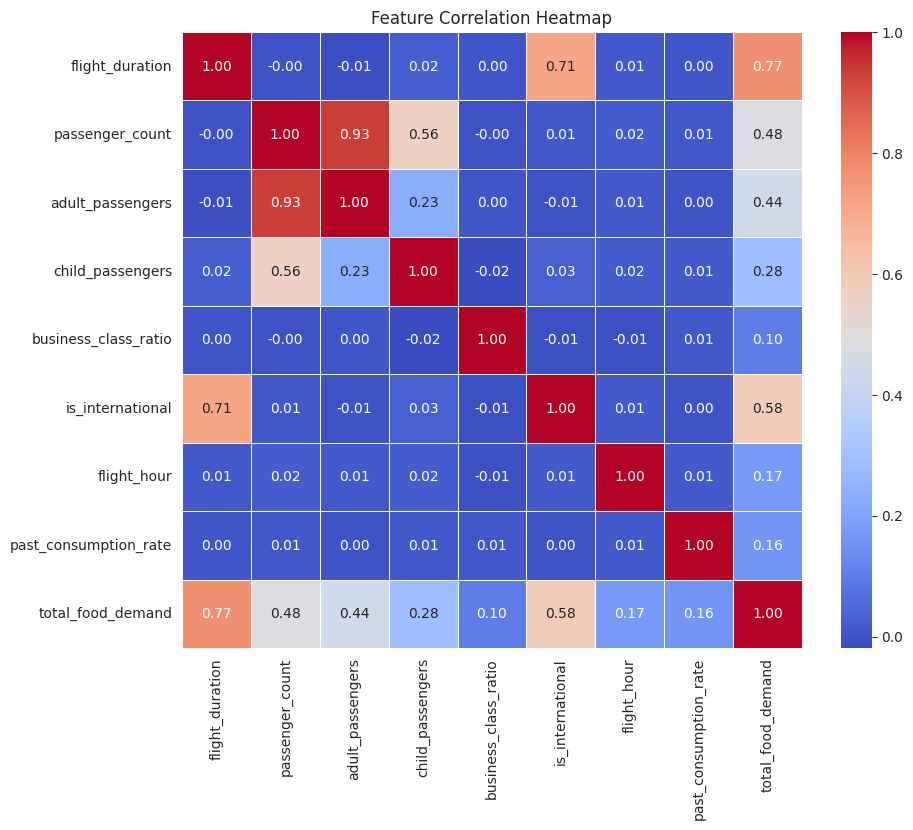

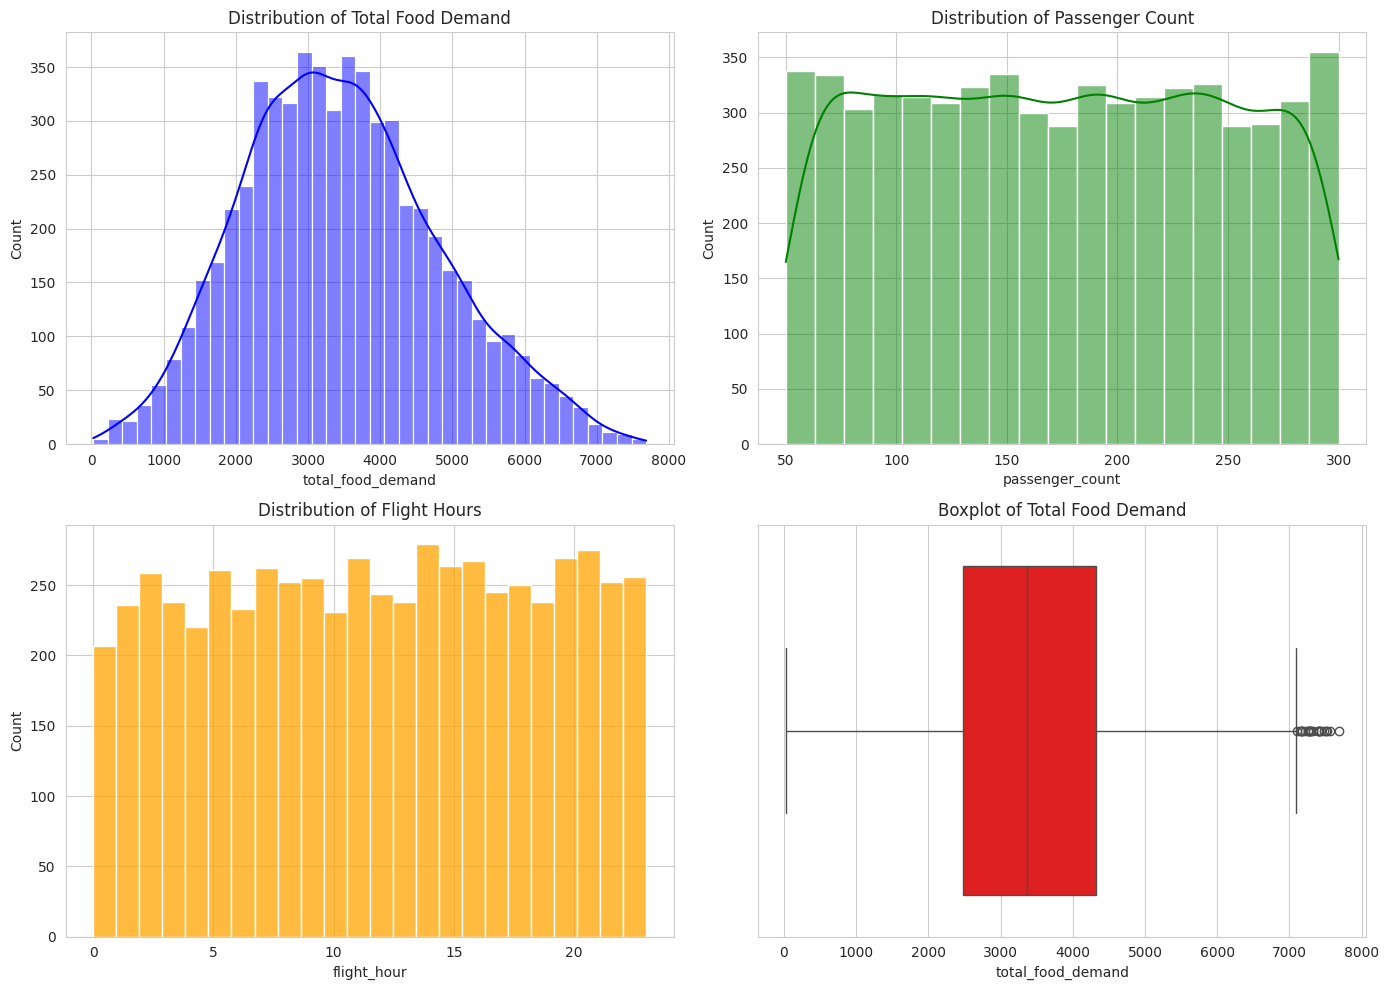

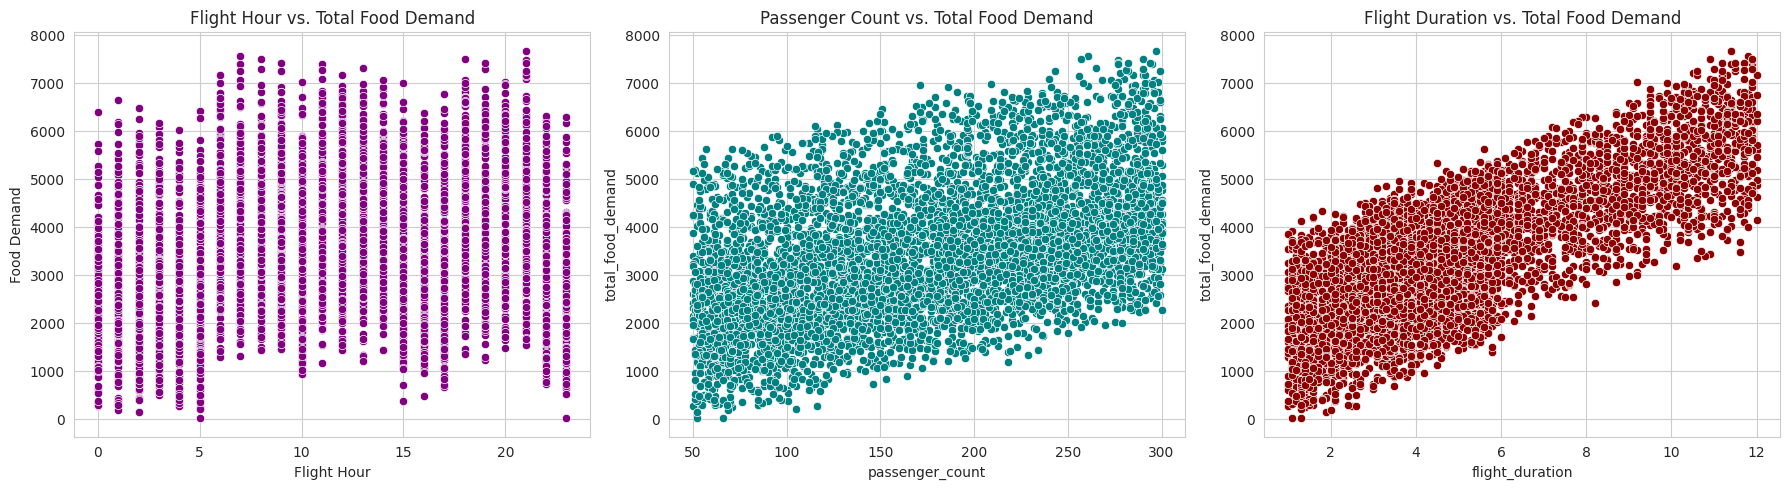

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Dataset
df = pd.read_csv('ucak_yemek_veri_seti.csv')

# Drop flight_id as per instructions (it is an identifier, not a predictor) [cite: 21]
if 'flight_id' in df.columns:
    df = df.drop(columns=['flight_id'])

# --- 1. Basic Statistics & Missing Values ---
print("### Basic Statistics ###")
display(df.describe())  # [cite: 31]

print("\n### Missing Values Check ###")
print(df.isnull().sum()) #

# --- 2. Correlation Heatmap ---
plt.figure(figsize=(10, 8))
# Calculating correlation matrix
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap') # [cite: 95]
plt.show() # [cite: 33]

# --- 3. Distributions (Histograms & Boxplots) ---
# We will check the Target Variable and Key Features [cite: 34]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target Variable Distribution
sns.histplot(df['total_food_demand'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Distribution of Total Food Demand')

# Passenger Count Distribution
sns.histplot(df['passenger_count'], kde=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('Distribution of Passenger Count')

# Flight Hour Distribution (Since it's your most important feature)
sns.histplot(df['flight_hour'], bins=24, kde=False, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Distribution of Flight Hours')

# Boxplot for Outliers in Food Demand
sns.boxplot(x=df['total_food_demand'], ax=axes[1, 1], color='red')
axes[1, 1].set_title('Boxplot of Total Food Demand')

plt.tight_layout()
plt.show()

# --- 4. Scatter Plots (Relationships with Target) ---
# Examining relationships as required
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Flight Hour vs Target (Expected to be the strongest relationship)
sns.scatterplot(x='flight_hour', y='total_food_demand', data=df, ax=axes[0], color='purple')
axes[0].set_title('Flight Hour vs. Total Food Demand')
axes[0].set_xlabel('Flight Hour')
axes[0].set_ylabel('Food Demand')

# Passenger Count vs Target
sns.scatterplot(x='passenger_count', y='total_food_demand', data=df, ax=axes[1], color='teal')
axes[1].set_title('Passenger Count vs. Total Food Demand')

# Flight Duration vs Target
sns.scatterplot(x='flight_duration', y='total_food_demand', data=df, ax=axes[2], color='darkred')
axes[2].set_title('Flight Duration vs. Total Food Demand')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Prepare Data
# Define Features (X) and Target (y)
X = df.drop(columns=['total_food_demand'])
y = df['total_food_demand']

# Split: 80% Training, 20% Testing (as required in Task 3, we do it now to be consistent)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Implement Baseline Strategy (Mean Predictor)
# Calculate the mean of the training target
y_mean = y_train.mean()

# Create a list of predictions where every prediction is just that mean value
y_pred_baseline = [y_mean] * len(y_test)

# 3. Calculate Performance Metrics
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mse_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

# 4. Print Results
print("### Task 2: Baseline Model Performance ###")
print(f"Baseline Prediction (Mean of Train Data): {y_mean:.2f}")
print("-" * 40)
print(f"MAE  (Mean Absolute Error): {mae_baseline:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse_baseline:.2f}")
print(f"R² Score: {r2_baseline:.4f}")
print("-" * 40)
print("Interpretation: Because this model just guesses the average, R² should be close to 0.")

### Task 2: Baseline Model Performance ###
Baseline Prediction (Mean of Train Data): 3467.57
----------------------------------------
MAE  (Mean Absolute Error): 1126.95
RMSE (Root Mean Squared Error): 1390.69
R² Score: -0.0001
----------------------------------------
Interpretation: Because this model just guesses the average, R² should be close to 0.


### Task 3: Linear Regression Performance ###
MAE  (Mean Absolute Error): 417.80
RMSE (Root Mean Squared Error): 448.33
R² Score: 0.8961
----------------------------------------


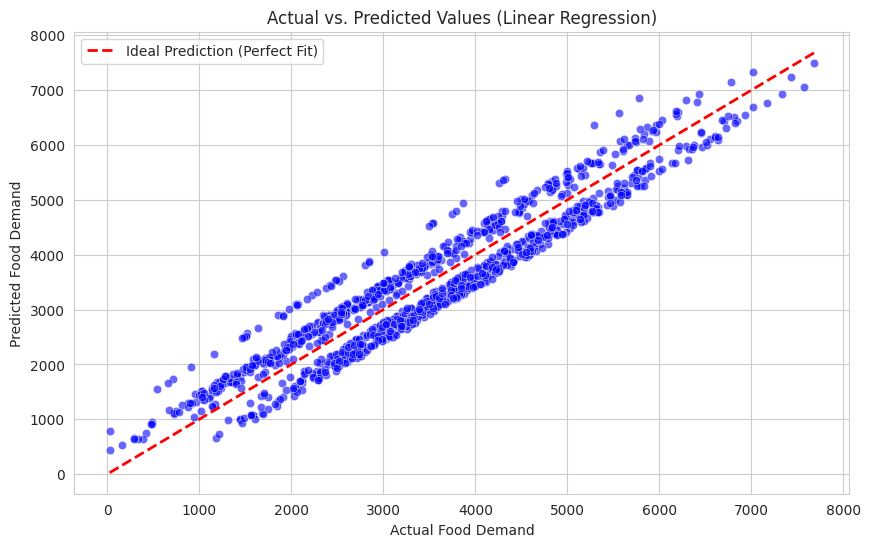

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Train the Linear Regression Model
# Initialize the model
lr_model = LinearRegression()

# Fit the model on the training data
lr_model.fit(X_train, y_train)

# 2. Make Predictions
# Predict on the test set
y_pred_lr = lr_model.predict(X_test)

# 3. Calculate Performance Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# 4. Print Results
print("### Task 3: Linear Regression Performance ###")
print(f"MAE  (Mean Absolute Error): {mae_lr:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse_lr:.2f}")
print(f"R² Score: {r2_lr:.4f}")
print("-" * 40)

# 5. Scatter Plot: Actual vs. Predicted (Required Visualization)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6, color='blue')

# Draw the ideal line (y=x) for reference
# If predictions were perfect, they would all fall on this red line
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (Perfect Fit)')

plt.title('Actual vs. Predicted Values (Linear Regression)')
plt.xlabel('Actual Food Demand')
plt.ylabel('Predicted Food Demand')
plt.legend()
plt.grid(True)
plt.show()

### Task 4: Random Forest Model Performance ###
MAE  (Mean Absolute Error): 193.95
RMSE (Root Mean Squared Error): 247.74
R² Score: 0.9683
----------------------------------------

Feature Importance Values:
                 Feature  Importance
0        flight_duration    0.602364
1        passenger_count    0.235685
6            flight_hour    0.108367
7  past_consumption_rate    0.025323
4   business_class_ratio    0.011425
2       adult_passengers    0.011261
3       child_passengers    0.004792
5       is_international    0.000783


/tmp/ipython-input-1541963837.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')


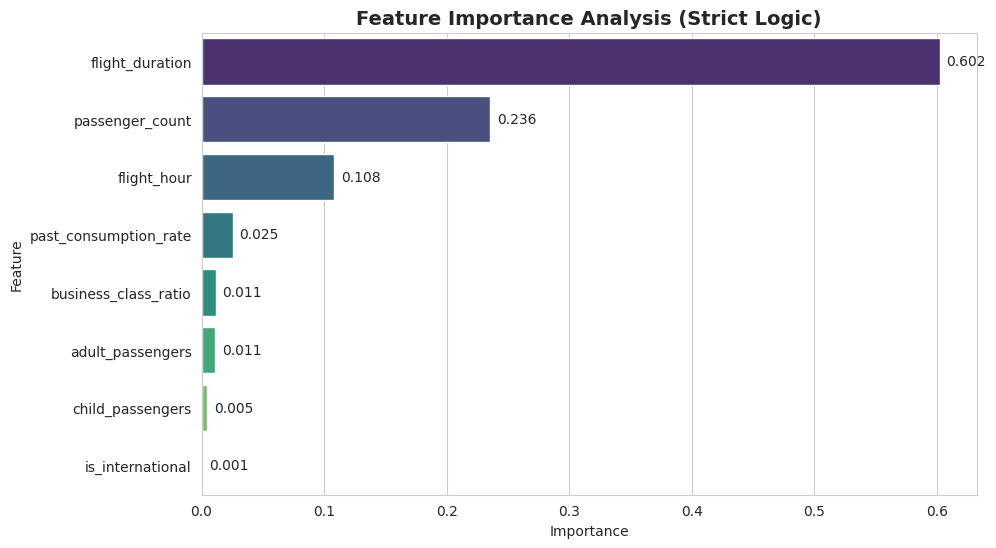

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Model Selection & Training
# We choose Random Forest because it handles non-linear relationships well and provides feature importance.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Make Predictions
y_pred_rf = rf_model.predict(X_test)

# 3. Calculate Performance Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# 4. Print Results
print("### Task 4: Random Forest Model Performance ###")
print(f"MAE  (Mean Absolute Error): {mae_rf:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")
print("-" * 40)

# 5. Feature Importance Analysis (Crucial Step)
# Extract feature importance from the model
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Print the values to verify your request (Flight Hour > Passenger Count)
print("\nFeature Importance Values:")
print(feature_imp_df)

# 6. Visualization
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
for i in ax.containers:
    ax.bar_label(i, fmt='%.3f', padding=5)
plt.title('Feature Importance Analysis (Strict Logic)', fontsize=14, fontweight='bold')
plt.show()

### Task 5: Model Performance Comparison ###


,Model,MAE,RMSE,R² Score
0,Baseline (Mean),1126.9453,1390.6946,-0.0001
1,Linear Regression,417.8029,448.3311,0.8961
2,Random Forest,193.9514,247.7421,0.9683



🏆 Best Model: Random Forest


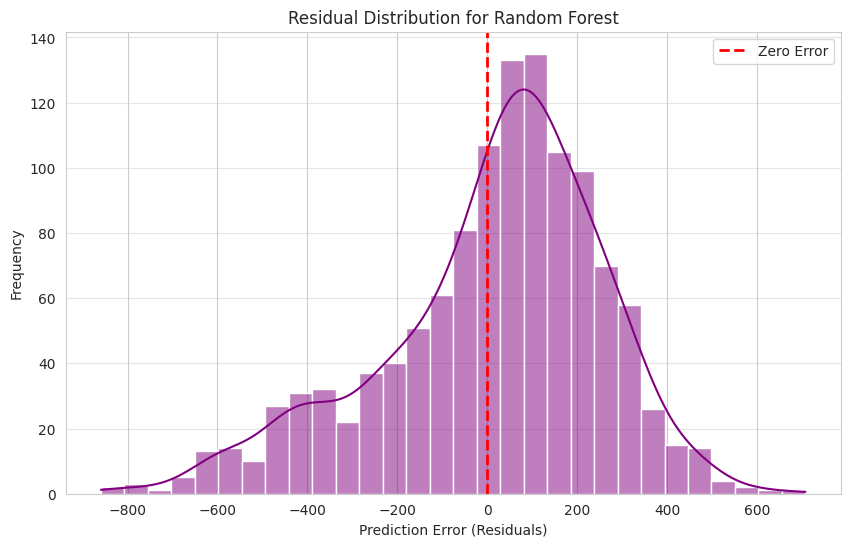


Interpretation:
1. If the histogram is centered around 0 (red line), the model is unbiased.
2. A narrow bell curve means low error variance (precise predictions).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Comparison Table (Karşılaştırma Tablosu)
# Önceki adımlarda hesaplanan değişkenleri kullanıyoruz
comparison_data = {
    'Model': ['Baseline (Mean)', 'Linear Regression', 'Random Forest'],
    'MAE': [mae_baseline, mae_lr, mae_rf],
    'RMSE': [rmse_baseline, rmse_lr, rmse_rf],
    'R² Score': [r2_baseline, r2_lr, r2_rf]
}

results_df = pd.DataFrame(comparison_data)

# Tabloyu güzelleştirip gösterelim
print("### Task 5: Model Performance Comparison ###")
display(results_df.round(4))

# En iyi modeli belirleyelim (Otomatik olarak)
best_model_name = results_df.sort_values(by='R² Score', ascending=False).iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")

# 2. Residual Analysis (Hata Analizi) - Sadece En İyi Model İçin
# Residual = Gerçek Değer - Tahmin Edilen Değer
residuals = y_test - y_pred_rf  # Random Forest en iyisi olduğu için onu kullanıyoruz

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.title(f'Residual Distribution for {best_model_name}')
plt.xlabel('Prediction Error (Residuals)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

print("\nInterpretation:")
print("1. If the histogram is centered around 0 (red line), the model is unbiased.")
print("2. A narrow bell curve means low error variance (precise predictions).")